### V_CRG_STUDENT_COURSE — Preprocessing V5

Scope:
- Work only on `V_CRG_STUDENT_COURSE`.
- Load raw Parquet.
- Preserve raw data and original ID values.
- Create clean attempts, normalized attempts, and current student-course status.
- Do not build models, course difficulty, or recommendation logic.

In [3]:
from pathlib import Path
from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

VERSION = "v5"

PROJECT_ROOT = Path(r"D:/AI/Real projects/Academic_Advisor")

RAW_PATH = PROJECT_ROOT / "data" / "raw" /  "v_crg_student_course_raw.parquet"

PREPROCESSED_DIR = PROJECT_ROOT / "data" / "preprocessed" / "V_CRG_STUDENT_COURSE"
FEATURES_DIR = PROJECT_ROOT / "data" / "features" / "V_CRG_STUDENT_COURSE"
REPORTS_DIR = PROJECT_ROOT / "reports" / "V_CRG_STUDENT_COURSE"

PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_PATH:", RAW_PATH)
print("PREPROCESSED_DIR:", PREPROCESSED_DIR)
print("FEATURES_DIR:", FEATURES_DIR)
print("REPORTS_DIR:", REPORTS_DIR)

assert RAW_PATH.exists(), f"Raw Parquet file not found: {RAW_PATH}" 

PROJECT_ROOT: D:\AI\Real projects\Academic_Advisor
RAW_PATH: D:\AI\Real projects\Academic_Advisor\data\raw\v_crg_student_course_raw.parquet
PREPROCESSED_DIR: D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE
FEATURES_DIR: D:\AI\Real projects\Academic_Advisor\data\features\V_CRG_STUDENT_COURSE
REPORTS_DIR: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE


### 1. Load raw Parquet file

This step loads the raw V5 Parquet file.  
No values are changed here.

In [4]:
df_raw_loaded_v5 = pd.read_parquet(RAW_PATH)

print("Raw loaded shape:", df_raw_loaded_v5.shape)
display(df_raw_loaded_v5.head())
display(df_raw_loaded_v5.dtypes) 

Raw loaded shape: (965467, 15)


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active
0,466289.111,1491.111,153.111,20111.0,684.111,37.0,0.00,F,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A
1,466290.111,1491.111,152.111,20111.0,684.111,48.0,0.00,F,مدخل الى القانون,C,19.111,إدارة الأعمال,7.111,2.0,A
2,466291.111,1491.111,150.111,20111.0,679.111,72.0,2.50,P,مهارات الحاسوب 1,C,19.111,إدارة الأعمال,7.111,3.0,A
3,466292.111,1491.111,149.111,20111.0,676.111,86.0,3.25,P,اللغة العربية,C,19.111,إدارة الأعمال,7.111,2.0,A
4,466293.111,1492.111,153.111,20111.0,684.111,12.0,0.00,F,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A


student_course_id    float64
student_id           float64
course_id            float64
part_id              float64
grade_id             float64
final_mark           float64
points               float64
finish_status            str
course_name_sl           str
study_mode               str
degree_id            float64
degree_name_sl           str
faculty_id           float64
course_credits       float64
active                   str
dtype: object

In [5]:
assert isinstance(df_raw_loaded_v5, pd.DataFrame)
assert len(df_raw_loaded_v5) > 0, "Raw dataframe is empty."

print("Validation passed: raw Parquet loaded successfully.") 

Validation passed: raw Parquet loaded successfully.


### 2. Standardize column names and validate required columns

Only column names are standardized to lowercase.  
Raw values remain unchanged.

In [7]:
df_raw_v5 = df_raw_loaded_v5.copy()

df_raw_v5.columns = (
    df_raw_v5.columns
    .astype(str)
    .str.strip()
    .str.lower()
)

required_raw_columns_v5 = [
    "student_course_id",
    "student_id",
    "course_id",
    "part_id",
    "grade_id",
    "final_mark",
    "points",
    "finish_status",
    "course_name_sl",
    "study_mode",
    "degree_id",
    "degree_name_sl",
    "faculty_id",
    "course_credits",
    "active",
]

missing_required_columns_v5 = sorted(set(required_raw_columns_v5) - set(df_raw_v5.columns))
extra_columns_v5 = sorted(set(df_raw_v5.columns) - set(required_raw_columns_v5))

print("Missing required columns:", missing_required_columns_v5)
print("Extra columns in source:", extra_columns_v5)

assert len(missing_required_columns_v5) == 0, f"Missing columns: {missing_required_columns_v5}"

df_raw_v5 = df_raw_v5[required_raw_columns_v5].copy()

print("Raw selected shape:", df_raw_v5.shape)
display(df_raw_v5.head()) 

Missing required columns: []
Extra columns in source: []
Raw selected shape: (965467, 15)


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active
0,466289.111,1491.111,153.111,20111.0,684.111,37.0,0.00,F,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A
1,466290.111,1491.111,152.111,20111.0,684.111,48.0,0.00,F,مدخل الى القانون,C,19.111,إدارة الأعمال,7.111,2.0,A
2,466291.111,1491.111,150.111,20111.0,679.111,72.0,2.50,P,مهارات الحاسوب 1,C,19.111,إدارة الأعمال,7.111,3.0,A
3,466292.111,1491.111,149.111,20111.0,676.111,86.0,3.25,P,اللغة العربية,C,19.111,إدارة الأعمال,7.111,2.0,A
4,466293.111,1492.111,153.111,20111.0,684.111,12.0,0.00,F,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A


In [8]:
assert list(df_raw_v5.columns) == required_raw_columns_v5
assert df_raw_v5.shape[1] == len(required_raw_columns_v5)

print("Validation passed: all required columns exist and selected.") 

Validation passed: all required columns exist and selected.


#### 3. save Raw profile report

This report gives a quick overview of row count, nulls, unique values, and dtype per column.

In [9]:
raw_profile_report_v5 = pd.DataFrame({
    "column": df_raw_v5.columns,
    "dtype": [str(df_raw_v5[col].dtype) for col in df_raw_v5.columns],
    "row_count": len(df_raw_v5),
    "non_null_count": [df_raw_v5[col].notna().sum() for col in df_raw_v5.columns],
    "null_count": [df_raw_v5[col].isna().sum() for col in df_raw_v5.columns],
    "null_ratio": [df_raw_v5[col].isna().mean() for col in df_raw_v5.columns],
    "unique_count": [df_raw_v5[col].nunique(dropna=True) for col in df_raw_v5.columns],
})

raw_profile_report_path_v5 = REPORTS_DIR / "raw_profile_report_v5.csv"
raw_profile_report_v5.to_csv(raw_profile_report_path_v5, index=False, encoding="utf-8-sig")

display(raw_profile_report_v5)
print("Saved:", raw_profile_report_path_v5) 

,column,dtype,row_count,non_null_count,null_count,null_ratio,unique_count
0,student_course_id,float64,965467,965467,0,0.000000,960175
1,student_id,float64,965467,965467,0,0.000000,16686
2,course_id,float64,965467,965466,1,0.000001,1114
3,part_id,float64,965467,965466,1,0.000001,67
4,grade_id,float64,965467,810710,154757,0.160292,57
5,final_mark,float64,965467,810284,155183,0.160734,101
6,points,float64,965467,810710,154757,0.160292,18
7,finish_status,str,965467,810693,154774,0.160310,13
8,course_name_sl,str,965467,965466,1,0.000001,938
9,study_mode,str,965467,965467,0,0.000000,1


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\raw_profile_report_v5.csv


In [10]:
assert raw_profile_report_path_v5.exists()
assert len(raw_profile_report_v5) == len(required_raw_columns_v5)

print("Validation passed: raw profile report saved.") 

Validation passed: raw profile report saved.


### 4. Null report

This report shows missing values per column.  
It is important before deciding archive/drop or critical issues.

In [11]:
null_report_v5 = (
    df_raw_v5
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "null_count"})
)

null_report_v5["row_count"] = len(df_raw_v5)
null_report_v5["null_ratio"] = null_report_v5["null_count"] / len(df_raw_v5)

null_report_v5 = null_report_v5.sort_values("null_count", ascending=False).reset_index(drop=True)

null_report_path_v5 = REPORTS_DIR / "null_report_v5.csv"
null_report_v5.to_csv(null_report_path_v5, index=False, encoding="utf-8-sig")

display(null_report_v5)
print("Saved:", null_report_path_v5)

,column,null_count,row_count,null_ratio
0,final_mark,155183,965467,0.160734
1,finish_status,154774,965467,0.160310
2,grade_id,154757,965467,0.160292
3,points,154757,965467,0.160292
4,degree_name_sl,121978,965467,0.126341
5,degree_id,34,965467,0.000035
6,faculty_id,34,965467,0.000035
7,course_credits,1,965467,0.000001
8,course_name_sl,1,965467,0.000001
9,part_id,1,965467,0.000001


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\null_report_v5.csv


In [12]:
assert null_report_path_v5.exists()
assert set(null_report_v5["column"]) == set(required_raw_columns_v5)

print("Validation passed: null report saved.")

Validation passed: null report saved.


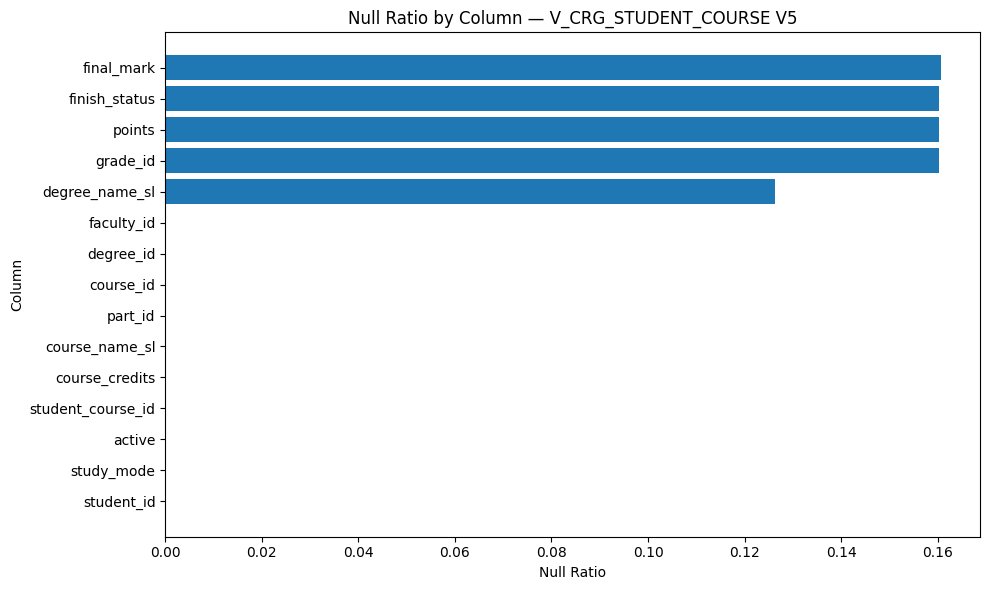

In [13]:
plot_df = null_report_v5.sort_values("null_ratio", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["column"], plot_df["null_ratio"])
plt.title("Null Ratio by Column — V_CRG_STUDENT_COURSE V5")
plt.xlabel("Null Ratio")
plt.ylabel("Column")
plt.tight_layout()
plt.show() 

#### 5. Finish status distribution

`finish_status` is the only official source for pass/fail outcome.  
`final_mark >= 50` must not be used as pass logic.

In [14]:
finish_status_distribution_v5 = (
    df_raw_v5["finish_status"]
    .astype("string")
    .str.strip()
    .str.upper()
    .fillna("<NULL>")
    .value_counts(dropna=False)
    .reset_index()
)

finish_status_distribution_v5.columns = ["finish_status", "count"]
finish_status_distribution_v5["row_count"] = len(df_raw_v5)
finish_status_distribution_v5["ratio"] = finish_status_distribution_v5["count"] / len(df_raw_v5)

finish_status_distribution_path_v5 = REPORTS_DIR / "finish_status_distribution_v5.csv"
finish_status_distribution_v5.to_csv(finish_status_distribution_path_v5, index=False, encoding="utf-8-sig")

display(finish_status_distribution_v5)
print("Saved:", finish_status_distribution_path_v5) 

,finish_status,count,row_count,ratio
0,P,618606,965467,0.640732
1,<NULL>,154774,965467,0.16031
2,F,96787,965467,0.100249
3,W,35982,965467,0.037269
4,T,19525,965467,0.020223
5,Z,13495,965467,0.013978
6,ST,12193,965467,0.012629
7,X,10584,965467,0.010963
8,D,1560,965467,0.001616
9,FA,1105,965467,0.001145


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\finish_status_distribution_v5.csv


In [15]:
assert finish_status_distribution_path_v5.exists()
assert finish_status_distribution_v5["count"].sum() == len(df_raw_v5)

print("Validation passed: finish_status distribution saved.") 

Validation passed: finish_status distribution saved.


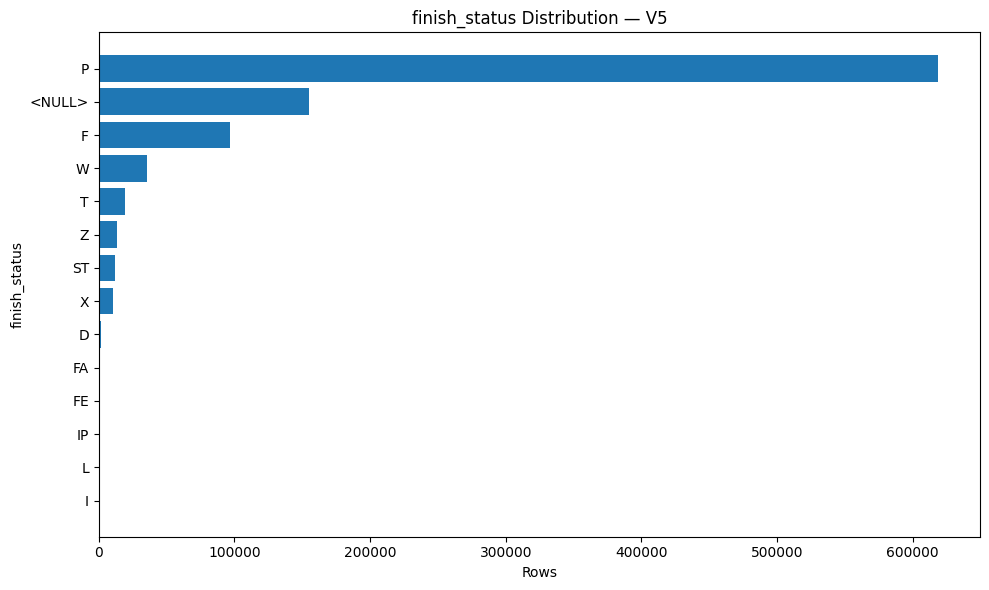

In [16]:
plot_df = finish_status_distribution_v5.sort_values("count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["finish_status"], plot_df["count"])
plt.title("finish_status Distribution — V5")
plt.xlabel("Rows")
plt.ylabel("finish_status")
plt.tight_layout()
plt.show() 

#### 6. Validate academic numeric columns

Rules:
- `final_mark` should be integer-like academic value.
- `course_credits` should be integer-like academic value.
- `points` should be float. 

In [17]:
def integer_like_report(df: pd.DataFrame, column: str) -> dict:
    numeric = pd.to_numeric(df[column], errors="coerce")
    non_null_numeric = numeric.dropna()
    fractional_count = int(((non_null_numeric % 1) != 0).sum())
    
    return {
        "column": column,
        "source_dtype": str(df[column].dtype),
        "non_null_count": int(df[column].notna().sum()),
        "numeric_count": int(non_null_numeric.shape[0]),
        "non_numeric_or_null_count": int(df[column].shape[0] - non_null_numeric.shape[0]),
        "fractional_count": fractional_count,
    }


numeric_validation_report_v5 = pd.DataFrame([
    integer_like_report(df_raw_v5, "final_mark"),
    integer_like_report(df_raw_v5, "course_credits"),
])

points_numeric = pd.to_numeric(df_raw_v5["points"], errors="coerce")

points_report_v5 = pd.DataFrame([{
    "column": "points",
    "source_dtype": str(df_raw_v5["points"].dtype),
    "non_null_count": int(df_raw_v5["points"].notna().sum()),
    "numeric_count": int(points_numeric.notna().sum()),
    "non_numeric_or_null_count": int(df_raw_v5["points"].shape[0] - points_numeric.notna().sum()),
    "fractional_count": np.nan,
}])

numeric_validation_report_v5 = pd.concat(
    [numeric_validation_report_v5, points_report_v5],
    ignore_index=True
)

display(numeric_validation_report_v5) 

,column,source_dtype,non_null_count,numeric_count,non_numeric_or_null_count,fractional_count
0,final_mark,float64,810284,810284,155183,0.0
1,course_credits,float64,965466,965466,1,9407.0
2,points,float64,810710,810710,154757,NaN


In [19]:
final_mark_fractional = numeric_validation_report_v5.loc[
    numeric_validation_report_v5["column"].eq("final_mark"),
    "fractional_count"
].iloc[0]

course_credits_fractional = numeric_validation_report_v5.loc[
    numeric_validation_report_v5["column"].eq("course_credits"),
    "fractional_count"
].iloc[0]

assert final_mark_fractional == 0, "final_mark has fractional values."
assert course_credits_fractional == 0, "course_credits has fractional values."

print("Validation passed: final_mark and course_credits are integer-like.")

AssertionError: course_credits has fractional values.